In [36]:
from langgraph.graph import StateGraph  , START , END

# add start and end dummy node dude 

from typing import TypedDict

In [48]:
#define the graph state 
class BMIState (TypedDict):
    weight_kg : float 
    height_m : float 
    bmi : float 
    category : str 


In [49]:

# all  node function live heres 

def calculate_Bmi(state : BMIState) -> BMIState:
    # extract weight and height from the state
    weight = state['weight_kg']
    height = state['height_m']
    #calculate the bmi 
    bmi = weight / (height **2 )
    # return the state 
    state['bmi'] = bmi 
    return state



def categorize_Bmi(state : BMIState) -> BMIState:
    # etract  the bmi 
    bmi = state['bmi']

    if bmi < 18.5 :
        category = 'UnderWeight'
    elif bmi < 25 :
        category = 'NormalWeight'
    elif bmi < 30 :
        category = 'OverWeight'
    else :
        category = 'Obese'  
    # now save the category in the state 
    state['category'] = category
    return state 


In [50]:
#define the graph 
graph = StateGraph(BMIState)


# add nodes to your graph 
graph.add_node(calculate_Bmi)
graph.add_node(categorize_Bmi)

# add edges to grpah 

graph.add_edge(START , 'calculate_Bmi')
graph.add_edge('calculate_Bmi' , 'categorize_Bmi')

graph.add_edge('categorize_Bmi' , END)

#visualise the graph 
graph.compile()

# compile the graph 
workFlow = graph.compile()
# execute the graph 


In [51]:
initial_state = BMIState(weight_kg=70 , height_m=1.75 , bmi=0.0, category="")
print(initial_state)

finalState = workFlow.invoke(input=initial_state)
print(finalState)


{'weight_kg': 70, 'height_m': 1.75, 'bmi': 0.0, 'category': ''}
{'weight_kg': 70, 'height_m': 1.75, 'bmi': 22.857142857142858, 'category': 'NormalWeight'}


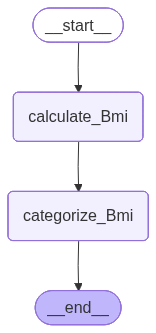

In [52]:
from IPython.display import Image
Image(workFlow.get_graph().draw_mermaid_png())

In [53]:
print(finalState['category'])


NormalWeight
